# Mapeo acoplado 2D tipo Lotka–Volterra (Solé y Valls, 1991)

En este notebook implementamos un **coupled map lattice (CML)** bidimensional
con:

- Tamaño de red: al menos 100x100
- Condiciones iniciales aleatorias
- Condiciones de frontera periódicas
- Mapeo local tipo Lotka–Volterra con difusión, inspirado en Solé y Valls (1991).

El objetivo es generar y visualizar los patrones espaciales que emergen.

## 1. Definir parámetros del modelo y de la simulación

- `N`: tamaño de la red (N x N).
- `a, b`: parámetros del mapeo Lotka–Volterra.
- `D1, D2`: coeficientes de difusión para `x` e `y`.
- `pasos`: número de iteraciones temporales totales.
- `seed`: semilla para reproducibilidad.

## 2. Definir funciones auxiliares

Incluimos:

- `heaviside_clamp(z)`: función tipo Heaviside para forzar poblaciones no negativas
  (H(z) = z si z > 0, 0 en otro caso).
- `laplacian_periodic(field)`: laplaciano discreto en 2D con fronteras periódicas.
- `inicializar_lattice(N, seed)`: condiciones iniciales aleatorias pequeñas.

## 4. Definir el paso de tiempo del CML (mapeo Lotka–Volterra + difusión)

Usamos como mapeo local la ecuación en diferencias inspirada en Solé y Valls:

\[
\begin{aligned}
x_{n+1}(i,j) &= H\big( a\,x_n(i,j)[1 - x_n(i,j) - y_n(i,j)] + D_1\,\Delta x_n(i,j) \big), \\
y_{n+1}(i,j) &= H\big( b\,x_n(i,j) + D_2\,\Delta y_n(i,j) \big).
\end{aligned}
\]

donde \(H\) es la función de Heaviside y \(\Delta\) es: 

$$\Delta x_{n}(r) = x_n(i,j+1) + x_n(i,j-1) + x_n(i-1,j) + x_n(i+1,j) -4x_n(i,j), $$





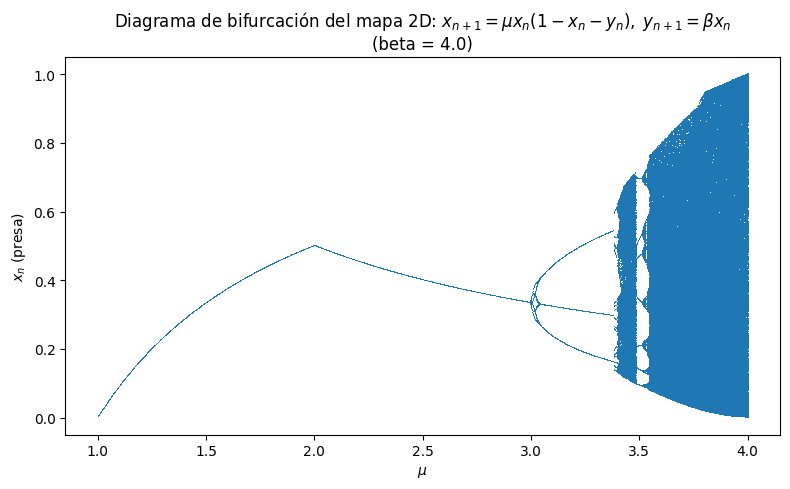

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from coupled_map_2D_v2 import bifurcation_diagram


mu_min = 1.0
mu_max = 4.0
n_mu   = 2000   

beta   = 4.0       

n_transient = 1000  
n_iter      = 1000   
x0 = 0.05
y0 = 0.05

mu_plot, x_plot = bifurcation_diagram(mu_min,mu_max,n_mu,
                                      beta,n_transient,n_iter,x0,y0)
plt.figure(figsize=(8, 5))
plt.plot(mu_plot, x_plot,',')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$x_n$ (presa)')
plt.title(r'Diagrama de bifurcación del mapa 2D: $x_{n+1} = \mu x_n(1 - x_n - y_n),\; y_{n+1} = \beta x_n$' + f'\n(beta = {beta})')
plt.tight_layout()
plt.show()


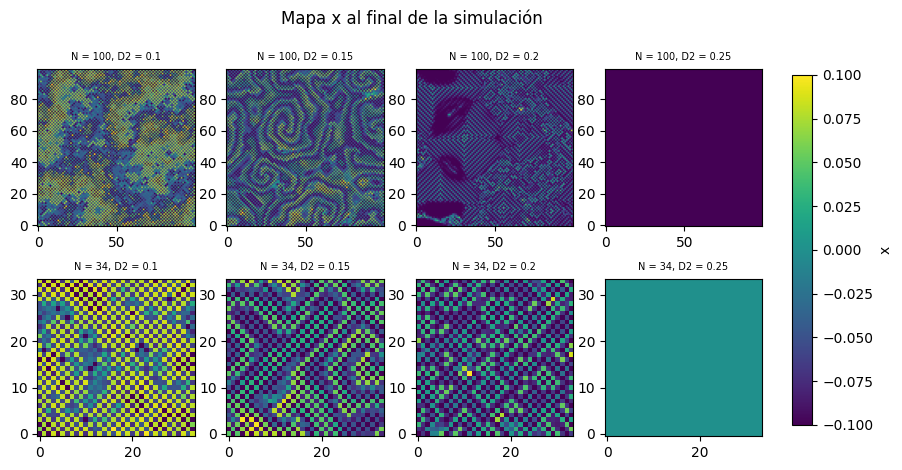

In [9]:
from coupledmap_2D import simular_lv_cml

campos = [[100,0.10],[100,0.15],[100,0.20],[100,0.25],[34,0.10],[34,0.15],[34,0.20],[34,0.25]]  

fig, axs = plt.subplots(2, 4, figsize=(10, 5))  
axs = axs.ravel()  

im = None
for k, ax in enumerate(axs):
    x, y = simular_lv_cml(N=campos[k][0], pasos=9_000, a=4.0, b=4.0, D1=0.099, D2=campos[k][1], seed=42)
    im = ax.imshow(x, origin="lower")
    ax.set_title(f"N = {campos[k][0]}, D2 = {campos[k][1]}", fontsize=7)

fig.subplots_adjust(right=0.85)

# Eje exclusivo para el colorbar: [left, bottom, width, height] en coords de figura
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="x")

fig.suptitle("Mapa x al final de la simulación", y=0.98)
# plt.tight_layout()
plt.show()



- Ajustando los parámetros de difusión `D1` y `D2`, así como `a` y `b`,
  se pueden observar diferentes patrones espaciales:
  - Parches (difusión más débil),
  - Ondas y espirales caóticas (difusión intermedia),
  - Patrones congelados (difusión más fuerte).

## Cálculo del exponente de Lyapunov máximo
Usaremos la idea de Wolf et al.:

1. Tomamos una trayectoria de referencia $(x_n, y_n)$.
2. Generamos una segunda trayectoria ligeramente perturbada $(x'_n, y'_n)$.
3. Evolucionamos ambas con el mismo mapa.
4. En cada paso medimos la norma de la diferencia $\|\delta \mathbf{X}_n\|$,
   donde $\delta \mathbf{X}_n = (x'_n - x_n,\, y'_n - y_n)$.
5. Calculamos el factor de crecimiento $g_n = \|\delta \mathbf{X}_n\| / \delta_0$,
   donde $\delta_0$ es la norma de referencia de la perturbación.
6. Renormalizamos la perturbación para que vuelva a tener norma $\delta_0$.
7. Finalmente, estimamos

$$\lambda_{\max} \approx \frac{1}{T} \sum_{n=1}^{T} \ln g_n.$$



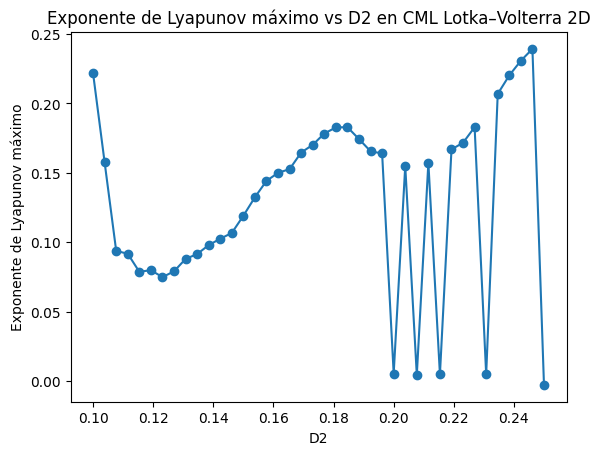

In [15]:
import matplotlib.pyplot as plt
lyaps = np.load("coupledmap2d/lyap_cml_a4_b4_D2.npy")
D2_vals, lambda_vals = zip(*lyaps)
plt.figure()
plt.plot(D2_vals, lambda_vals, marker="o", linestyle="-")
plt.xlabel("D2")
plt.ylabel("Exponente de Lyapunov máximo")
plt.title("Exponente de Lyapunov máximo vs D2 en CML Lotka–Volterra 2D")
plt.show()